In [1]:
!pip install tabulate

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Football Data Analysis") \
    .config("spark.master", "local[*]") \
    .getOrCreate()

In [3]:
# Define the HDFS path for the dataset
hdfs_path = "hdfs://namenode:9000/dataset/"

# Load DataFrames
appearances_df = spark.read.csv(hdfs_path + "appearances.csv", header=True, inferSchema=True)
clubs_df = spark.read.csv(hdfs_path + "clubs.csv", header=True, inferSchema=True)
games_df = spark.read.csv(hdfs_path + "games.csv", header=True, inferSchema=True)
player_valuations_df = spark.read.csv(hdfs_path + "player_valuations.csv", header=True, inferSchema=True)
club_games_df = spark.read.csv(hdfs_path + "club_games.csv", header=True, inferSchema=True)
players_df = spark.read.csv(hdfs_path + "players.csv", header=True, inferSchema=True)
game_lineups_df = spark.read.csv(hdfs_path + "game_lineups.csv", header=True,inferSchema=True)
game_events_df = spark.read.csv(hdfs_path + "game_events.csv", header=True, inferSchema=True)

In [5]:
# Data Preprocessing
# Drop unnecessary columns from appearances
appearances_df = appearances_df.drop(*[col for col in appearances_df.columns if col not in ['player_id', 'date', 'goals']])
clubs_df = clubs_df.drop(*[col for col in clubs_df.columns if col not in ['club_id', 'name']])
games_df = games_df.drop(*[col for col in games_df.columns if col not in ['game_id', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'season']])
player_valuations_df = player_valuations_df.drop(*[col for col in player_valuations_df.columns if col not in ['player_id', 'date', 'market_value_in_eur']])
club_games_df = club_games_df.drop(*[col for col in club_games_df.columns if col not in ['club_id', 'game_id']])
players_df = players_df.drop(*[col for col in players_df.columns if col not in ['player_id', 'current_club_id', 'name']])
game_lineups_df = game_lineups_df.drop(*[col for col in game_lineups_df.columns if col not in ['game_id', 'player_id', 'position']])
game_events_df = game_events_df.drop(*[col for col in game_events_df.columns if col not in ['game_id', 'player_id', 'type', 'minute']])

 # Fill missing goals with 0
appearances_df = appearances_df.na.fill({"goals": 0}) 

# Fill missing market values with 0
player_valuations_df = player_valuations_df.na.fill({"market_value_in_eur": 0})  

In [6]:
# Check the schema of each DataFrame after preprocessing
appearances_df.printSchema()
clubs_df.printSchema()
games_df.printSchema()
player_valuations_df.printSchema()
club_games_df.printSchema()
players_df.printSchema()
game_lineups_df.printSchema()
game_events_df.printSchema()

root
 |-- player_id: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- goals: integer (nullable = false)

root
 |-- club_id: integer (nullable = true)
 |-- name: string (nullable = true)

root
 |-- game_id: integer (nullable = true)
 |-- season: integer (nullable = true)
 |-- home_club_id: integer (nullable = true)
 |-- away_club_id: integer (nullable = true)
 |-- home_club_goals: integer (nullable = true)
 |-- away_club_goals: integer (nullable = true)

root
 |-- player_id: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- market_value_in_eur: integer (nullable = false)

root
 |-- game_id: integer (nullable = true)
 |-- club_id: integer (nullable = true)

root
 |-- player_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- current_club_id: integer (nullable = true)

root
 |-- game_id: integer (nullable = true)
 |-- player_id: integer (nullable = true)
 |-- position: string (nullable = true)

root
 |-- game_id: integer (nullable = tr

In [7]:
# Show the first 5 rows
appearances_df.show(5)
clubs_df.show(5)
games_df.show(5)
player_valuations_df.show(5)
club_games_df.show(5)
players_df.show(5)
game_lineups_df.show(5)
game_events_df.show(5)

+---------+----------+-----+
|player_id|      date|goals|
+---------+----------+-----+
|    38004|2012-07-03|    2|
|    79232|2012-07-05|    0|
|    42792|2012-07-05|    0|
|    73333|2012-07-05|    0|
|   122011|2012-07-05|    0|
+---------+----------+-----+
only showing top 5 rows

+-------+--------------------+
|club_id|                name|
+-------+--------------------+
|    105|     SV Darmstadt 98|
|  11127|  Ural Yekaterinburg|
|    114|Beşiktaş Jimnasti...|
|     12|Associazione Spor...|
|    148|Tottenham Hotspur...|
+-------+--------------------+
only showing top 5 rows

+-------+------+------------+------------+---------------+---------------+
|game_id|season|home_club_id|away_club_id|home_club_goals|away_club_goals|
+-------+------+------------+------------+---------------+---------------+
|2321044|  2013|          16|          23|              2|              1|
|2321060|  2013|          23|          24|              0|              2|
|2321086|  2013|           4|      

In [8]:
# Create temporary views for the DataFrames
appearances_df.createOrReplaceTempView("appearances")
clubs_df.createOrReplaceTempView("clubs")
games_df.createOrReplaceTempView("games")
player_valuations_df.createOrReplaceTempView("player_valuations")
club_games_df.createOrReplaceTempView("club_games")
players_df.createOrReplaceTempView("players")
game_lineups_df.createOrReplaceTempView('game_lineups')
game_events_df.createOrReplaceTempView("game_events")

Champions by season:
  season  club_name                          total_goals
    2012  Futbol Club Barcelona                      228
    2013  Real Madrid Club de Fútbol                 209
    2014  Real Madrid Club de Fútbol                 216
    2015  Futbol Club Barcelona                      224
    2016  Real Madrid Club de Fútbol                 245
    2017  Real Madrid Club de Fútbol                 217
    2018  AFC Ajax Amsterdam                         232
    2019  FC Bayern München                          209
    2020  FC Bayern München                          209
    2021  Liverpool Football Club                    203
    2022  Real Madrid Club de Fútbol                 196
    2023  Manchester City Football Club              203
    2024  Manchester United Football Club             74


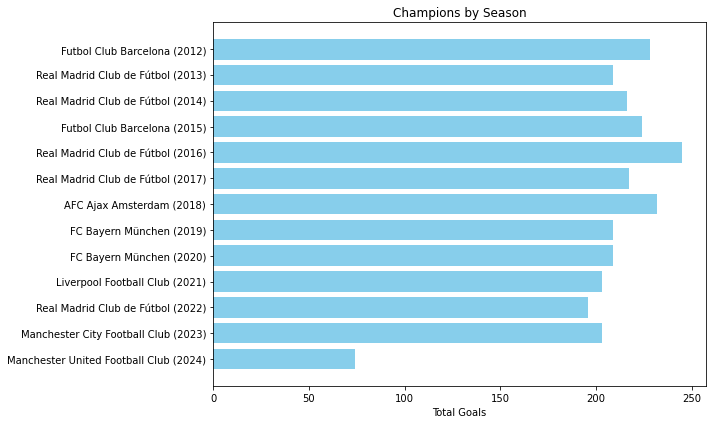

In [9]:
def get_champions_of_competition():
    """
    Retrieves the champions of a given competition by season.
    """
    query = """
    SELECT 
        season,
        club_name,
        total_goals
    FROM (
        SELECT 
            g.season,
            c.name AS club_name,
            SUM(g.home_club_goals + g.away_club_goals) AS total_goals,
            ROW_NUMBER() OVER (PARTITION BY g.season ORDER BY SUM(g.home_club_goals + g.away_club_goals) DESC) AS rank
        FROM 
            games g
        JOIN 
            clubs c ON g.home_club_id = c.club_id OR g.away_club_id = c.club_id
        GROUP BY 
            g.season, c.name
    ) ranked
    WHERE rank = 1
    ORDER BY season
    """
    return spark.sql(query)

def visualize_champions(champions_pd):
    plt.figure(figsize=(10, 6))
    plt.barh(champions_pd['club_name'] + ' (' + champions_pd['season'].astype(str) + ')', champions_pd['total_goals'], color='skyblue')
    plt.xlabel('Total Goals')
    plt.title('Champions by Season')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
champions_df = get_champions_of_competition()
champions_pd = champions_df.toPandas()
# Display the data for verification with seasons
print("Champions by season:")
print(tabulate(champions_pd, headers='keys', tablefmt='plain', showindex=False, stralign='left'))

# Visualize Champions
visualize_champions(champions_pd)

In [10]:
def get_club_performance_by_season(club_name1, club_name2, season):
    """
    Retrieves the performance of two specified clubs for a given season.
    """
    query = f"""
    SELECT 
        g.season,
        c.name AS club_name,
        COUNT(g.game_id) AS matches_played,
        SUM(CASE WHEN g.home_club_id = cg.club_id AND g.home_club_goals > g.away_club_goals THEN 1 
                 WHEN g.away_club_id = cg.club_id AND g.away_club_goals > g.home_club_goals THEN 1
                 ELSE 0 END) AS wins,
        SUM(CASE WHEN g.home_club_id = cg.club_id AND g.home_club_goals < g.away_club_goals THEN 1 
                 WHEN g.away_club_id = cg.club_id AND g.away_club_goals < g.home_club_goals THEN 1
                 ELSE 0 END) AS losses,
        SUM(CASE WHEN g.home_club_id = cg.club_id AND g.home_club_goals = g.away_club_goals THEN 1 
                 WHEN g.away_club_id = cg.club_id AND g.away_club_goals = g.home_club_goals THEN 1
                 ELSE 0 END) AS draws
    FROM 
        club_games cg
    JOIN 
        games g ON cg.game_id = g.game_id
    JOIN 
        clubs c ON cg.club_id = c.club_id
    WHERE 
        (c.name = '{club_name1}' OR c.name = '{club_name2}') AND g.season = '{season}'
    GROUP BY 
        g.season, c.name
    ORDER BY 
        g.season
    """
    return spark.sql(query)

def visualize_club_performance_comparison(performance_pd):
    """
    Visualizes the performance metrics of two clubs for a given season with data values on the bars.
    """
    categories = ['wins', 'losses', 'draws']
    
    # Create a bar width
    bar_width = 0.35
    
    # Bar positions for two clubs
    x = range(len(categories))
    
    # Plotting the bars for both clubs
    bar1 = plt.bar(x, performance_pd[performance_pd['club_name'] == performance_pd['club_name'].iloc[0]][categories].values[0], 
                   width=bar_width, label=performance_pd['club_name'].iloc[0], color='gold')
    bar2 = plt.bar([p + bar_width for p in x], performance_pd[performance_pd['club_name'] == performance_pd['club_name'].iloc[1]][categories].values[0], 
                   width=bar_width, label=performance_pd['club_name'].iloc[1], color='blue')

    # Adding data values on the bars
    for bar in bar1 + bar2:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom')

    plt.xlabel('Performance Metrics')
    plt.ylabel('Number of Matches')
    plt.title(f"Comparison of {performance_pd['club_name'].iloc[0]} and {performance_pd['club_name'].iloc[1]} in {performance_pd['season'].iloc[0]}")
    plt.xticks([p + bar_width / 2 for p in x], categories)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [11]:
# Replace with the desired club names
club_name1 = 'Real Madrid Club de Fútbol'
club_name2 = 'Futbol Club Barcelona'
# Replace with the desired season
season = 2022  


Performance of 'Real Madrid Club de Fútbol' and 'Futbol Club Barcelona' in 2022:
   season                   club_name  matches_played  wins  losses  draws
0    2022  Real Madrid Club de Fútbol              61    41      12      8
1    2022       Futbol Club Barcelona              53    36      11      6


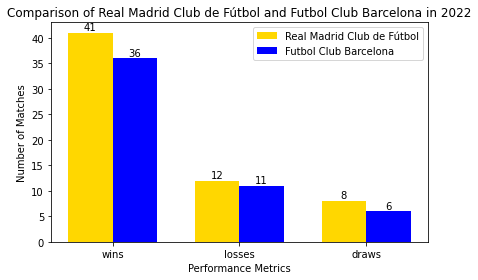

In [12]:
# Get club performance for the specified clubs and season
club_performance_comparison_df = get_club_performance_by_season(club_name1, club_name2, season)
club_performance_comparison_pd = club_performance_comparison_df.toPandas()

# Print the performance data
if not club_performance_comparison_pd.empty:
    print(f"\nPerformance of '{club_name1}' and '{club_name2}' in {season}:")
    print(club_performance_comparison_pd)
    
    # Visualize Club Performance Comparison
    visualize_club_performance_comparison(club_performance_comparison_pd)
else:
    print(f"No data available for '{club_name1}' and '{club_name2}' in {season}.")


Highest Goal Scorer by season:
  season  name                  total_goals
    2012  Lionel Messi                   35
    2013  Cristiano Ronaldo              59
    2014  Cristiano Ronaldo              56
    2015  Cristiano Ronaldo              54
    2016  Lionel Messi                   51
    2017  Lionel Messi                   50
    2018  Lionel Messi                   47
    2019  Robert Lewandowski             48
    2020  Robert Lewandowski             45
    2021  Robert Lewandowski             58
    2022  Kylian Mbappé                  41
    2023  Erling Haaland                 44
    2024  Viktor Gyökeres                32


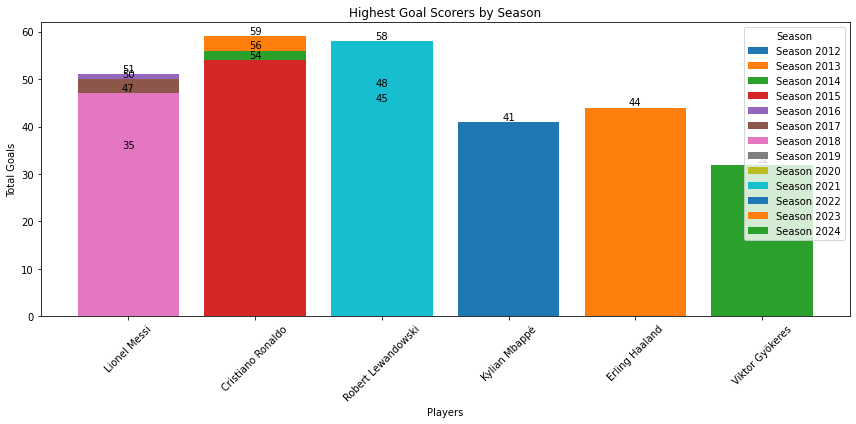

In [13]:
def get_highest_goal_scorer():
    """
    Retrieves the highest goal scorer for each season.
    """
    query = """
    WITH seasonal_goals AS (
        SELECT 
            YEAR(a.date) AS season,
            p.name,
            SUM(a.goals) AS total_goals
        FROM 
            appearances a
        JOIN 
            players p ON a.player_id = p.player_id
        GROUP BY 
            YEAR(a.date), p.name
    )
    SELECT 
        season,
        name,
        total_goals
    FROM 
        seasonal_goals
    WHERE 
        (season, total_goals) IN (
            SELECT 
                season, 
                MAX(total_goals) 
            FROM 
                seasonal_goals 
            GROUP BY 
                season
        )
    ORDER BY 
        season
    """
    return spark.sql(query)

def visualize_highest_goal_scorer(highest_goal_scorer_pd):
    plt.figure(figsize=(12, 6))
    for season in highest_goal_scorer_pd['season'].unique():
        data = highest_goal_scorer_pd[highest_goal_scorer_pd['season'] == season]
        bars = plt.bar(data['name'], data['total_goals'], label=f'Season {season}')

        # Annotate the bars with the data values
        for bar in bars:
            yval = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2, 
                yval, 
                f'{int(yval)}', 
                va='bottom', 
                ha='center', 
                fontsize=10, 
                color='black'
            )

    plt.xlabel('Players')
    plt.ylabel('Total Goals')
    plt.title('Highest Goal Scorers by Season')
    plt.xticks(rotation=45)
    plt.legend(title='Season')
    plt.tight_layout()
    plt.show()

highest_goal_scorer_df = get_highest_goal_scorer()
highest_goal_scorer_pd = highest_goal_scorer_df.toPandas()
print("\nHighest Goal Scorer by season:")
print(tabulate(highest_goal_scorer_pd, headers='keys', tablefmt='plain', showindex=False, stralign='left'))

# Visualize Highest Goal Scorers
visualize_highest_goal_scorer(highest_goal_scorer_pd)


Highest Paid Player for Each Season Over the Last 5 Seasons:
  season  player_name          highest_market_value
    2024  Erling Haaland                  200000000
    2023  Erling Haaland                  180000000
    2022  Kylian Mbappé                   180000000
    2021  Kylian Mbappé                   160000000
    2020  Kylian Mbappé                   180000000
    2019  Kylian Mbappé                   200000000
    2018  Kylian Mbappé                   200000000
    2017  Neymar                          150000000
    2016  Lionel Messi                    120000000
    2015  Cristiano Ronaldo               120000000


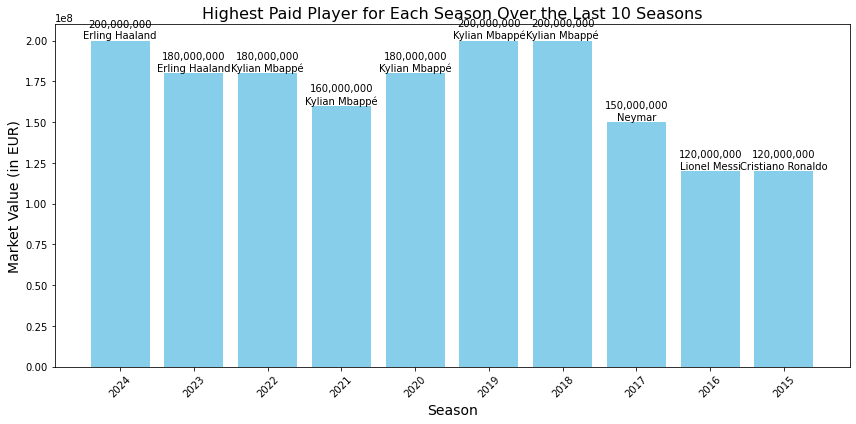

In [14]:
def get_highest_paid_player_each_season():
    """
    Retrieves the highest-paid player for each season over the last 5 seasons.
    """
    query = """
    WITH RankedPlayers AS (
        SELECT 
            YEAR(pv.date) AS season,
            pl.name AS player_name,
            pv.market_value_in_eur AS market_value,
            ROW_NUMBER() OVER (PARTITION BY YEAR(pv.date) ORDER BY pv.market_value_in_eur DESC) AS rank
        FROM 
            player_valuations pv
        JOIN 
            players pl ON pv.player_id = pl.player_id
        WHERE 
            YEAR(pv.date) >= YEAR(current_date()) - 9  -- Limit to last 10 seasons
    )
    SELECT 
        season,
        player_name,
        market_value AS highest_market_value
    FROM 
        RankedPlayers
    WHERE 
        rank = 1  -- Get only the highest-paid player for each season
    ORDER BY 
        season DESC  -- Order by season descending
    """
    return spark.sql(query)

# Fetching the data
highest_paid_players_df = get_highest_paid_player_each_season()
highest_paid_players_pd = highest_paid_players_df.toPandas()


highest_paid_players_pd['season'] = highest_paid_players_pd['season'].astype(str)

print("\nHighest Paid Player for Each Season Over the Last 5 Seasons:")
print(tabulate(highest_paid_players_pd, headers='keys', tablefmt='plain', showindex=False, stralign='left'))

def visualize_highest_paid_players(highest_paid_players_pd):
    """
    Visualizes the highest-paid player for each season with their names and market values.
    """
    # Set the figure size
    plt.figure(figsize=(12, 6))

    # Create a bar chart
    bars = plt.bar(highest_paid_players_pd['season'], highest_paid_players_pd['highest_market_value'], color='skyblue')

    # Adding title and labels
    plt.title('Highest Paid Player for Each Season Over the Last 10 Seasons', fontsize=16)
    plt.xlabel('Season', fontsize=14)
    plt.ylabel('Market Value (in EUR)', fontsize=14)

    # Rotate x-ticks for better readability
    plt.xticks(rotation=45)

    # Display market value and player name on top of the bars
    for index, bar in enumerate(bars):
        value = highest_paid_players_pd['highest_market_value'][index]
        player_name = highest_paid_players_pd['player_name'][index]
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), 
                 f'{value:,.0f}\n{player_name}', 
                 ha='center', va='bottom', fontsize=10)

    # Show the plot
    plt.tight_layout()
    plt.show()

# Call the visualization function
visualize_highest_paid_players(highest_paid_players_pd)

In [19]:
def get_player_market_value_over_seasons(player_name1, player_name2):
    """
    Retrieves the market value of two players over the last 10 seasons.
    """
    query = f"""
    SELECT 
        YEAR(pv.date) AS season,
        pl.name AS player_name,
        MAX(pv.market_value_in_eur) AS market_value
    FROM 
        player_valuations pv
    JOIN 
        players pl ON pv.player_id = pl.player_id
    WHERE 
        (pl.name = '{player_name1}' OR pl.name = '{player_name2}')
        AND YEAR(pv.date) >= YEAR(current_date()) - 10  -- Limit to last 10 seasons
    GROUP BY 
        season, pl.name
    ORDER BY 
        season DESC, pl.name
    """
    return spark.sql(query)

def visualize_players_market_value(player_market_value_pd, player_name1, player_name2):
    """
    Visualizes the market value of two players over the last 10 seasons.
    """
    # Plotting the market value for each player
    plt.figure(figsize=(12, 6))
    
    for player in [player_name1, player_name2]:
        player_data = player_market_value_pd[player_market_value_pd['player_name'] == player]
        plt.plot(player_data['season'], player_data['market_value'], marker='o', linestyle='-', label=f'{player}')
        
        # Annotate the points
        for i, row in player_data.iterrows():
            plt.annotate(f'{row["market_value"]:,}', 
                         (row['season'], row['market_value']),
                         textcoords="offset points", 
                         xytext=(0, 10), 
                         ha='center')
    
    # Adding plot details
    plt.title(f'Market Value Comparison: {player_name1} vs. {player_name2} Over the Last 10 Seasons')
    plt.xlabel('Season')
    plt.ylabel('Market Value (in EUR)')
    plt.legend(title='Player')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

In [20]:
# Define the player names
player1 = 'Lionel Messi'
player2 = 'Kylian Mbappé'


Market Value Comparison Over the Last 10 Seasons:
    season    player_name  market_value
0     2024  Kylian Mbappé     180000000
1     2023  Kylian Mbappé     180000000
2     2023   Lionel Messi      45000000
3     2022  Kylian Mbappé     180000000
4     2022   Lionel Messi      50000000
5     2021  Kylian Mbappé     160000000
6     2021   Lionel Messi      80000000
7     2020  Kylian Mbappé     180000000
8     2020   Lionel Messi     112000000
9     2019  Kylian Mbappé     200000000
10    2019   Lionel Messi     150000000
11    2018  Kylian Mbappé     200000000
12    2018   Lionel Messi     180000000
13    2017  Kylian Mbappé      90000000
14    2017   Lionel Messi     120000000
15    2016  Kylian Mbappé       4000000
16    2016   Lionel Messi     120000000
17    2015  Kylian Mbappé         50000
18    2015   Lionel Messi     120000000
19    2014   Lionel Messi     120000000


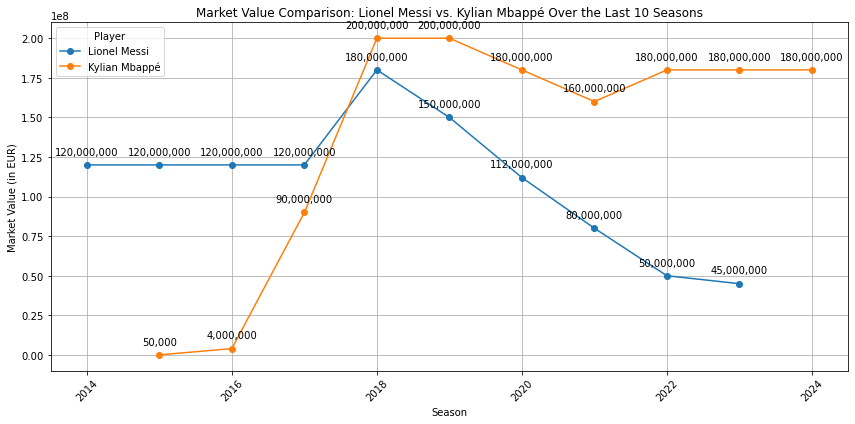

In [21]:
# Fetch the player market value data
players_market_value_df = get_player_market_value_over_seasons(player1, player2)
players_market_value_pd = players_market_value_df.toPandas()

# Print the data
print("\nMarket Value Comparison Over the Last 10 Seasons:")
print(players_market_value_pd)

# Visualize the players' market value
visualize_players_market_value(players_market_value_pd, player1, player2)